[*********************100%***********************]  1 of 1 completed


StockLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)
Epoch [10/100], Loss: 0.022817
Epoch [20/100], Loss: 0.004799
Epoch [30/100], Loss: 0.002759
Epoch [40/100], Loss: 0.001512
Epoch [50/100], Loss: 0.000812
Epoch [60/100], Loss: 0.000428
Epoch [70/100], Loss: 0.000354
Epoch [80/100], Loss: 0.000290
Epoch [90/100], Loss: 0.000271
Epoch [100/100], Loss: 0.000255
학습 완료


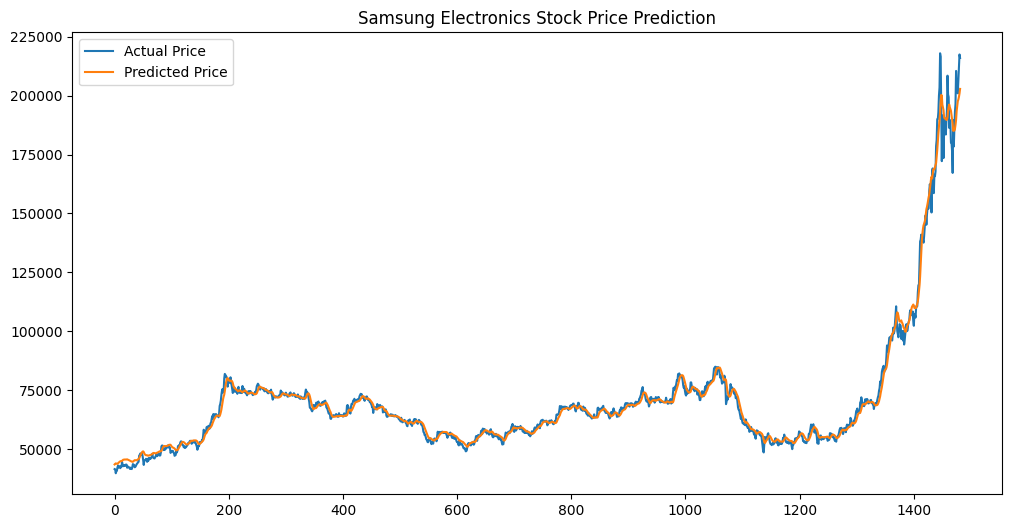

In [10]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 데이터 불러오기 (삼성전자)
df = yf.download('005930.KS', start='2020-01-01', end='2026-04-20')
data = df[['Close']].values # 종가만 사용

# 2. 데이터 정규화 (0~1 사이로)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# 3. 윈도우 데이터 생성 (과거 60일을 보고 다음날 예측)
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

seq_length = 60
X, y = create_sequences(data_scaled, seq_length)

# 텐서로 변환
X_train = torch.FloatTensor(X)
y_train = torch.FloatTensor(y)

# 4. LSTM 모델 정의
class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(StockLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Batch Normalization 대신 안정적인 LSTM 설계
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x.device를 사용하여 h0, c0를 x가 있는 장치(MPS)에 똑같이 만듭니다.
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
    
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# 모델 생성
model = StockLSTM(input_size=1, hidden_size=50, num_layers=2, output_size=1)
print(model)

# 1. GPU(MPS) 또는 CPU 설정
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model.to(device)

# 2. 손실 함수와 최적화 도구 설정
criterion = nn.MSELoss()  # 평균 제곱 오차 (회귀 문제의 국룰)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # 학습률 0.01

# 3. 학습 시작
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    
    # 데이터를 장치(GPU/CPU)로 이동
    inputs = X_train.to(device)
    targets = y_train.to(device)
    
    # Forward pass: 예측값 계산
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    
    # Backward pass: 오차 역전파 및 가중치 업데이트
    optimizer.zero_grad() # 이전 루프의 기울기 초기화
    loss.backward()       # 기울기 계산
    optimizer.step()      # 가중치 수정
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

print("학습 완료")

model.eval() # 평가 모드 전환
with torch.no_grad():
    predicted = model(X_train.to(device)).cpu().numpy()

# 정규화되었던 데이터를 다시 원래 가격 단위로 되돌리기
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_train.numpy())

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title('Samsung Electronics Stock Price Prediction')
plt.legend()
plt.show()

